In [1]:
from astropy.io import fits
from astropy import units as u
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from astropy.visualization import quantity_support
quantity_support()

sdss_general_path = "C:/Users/lrik/Work"
sdss_filename_fits = "specObj-dr17.fits"
sdss_path = f"{sdss_general_path}/{sdss_filename_fits}"

spec_path = "C:/Users/lrik/Work/spectra"

from specutils import SpectralRegion

In [2]:
fix_number = lambda x: ('0000' + str(x))[-4:] if len(str(x)) < 5 else str(x)
file_path = lambda i, x: f"{spec_path}/{x.loc[i,'RUN2D']}/{fix_number(x.loc[i,'PLATE'])}/spec-{fix_number(x.loc[i,'PLATE'])}-{x.loc[i,'MJD']}-{fix_number(x.loc[i,'FIBERID'])}.fits"
file_name = lambda i, x: f"spec-{fix_number(x.loc[i,'PLATE'])}-{x.loc[i,'MJD']}-{fix_number(x.loc[i,'FIBERID'])}"

In [76]:
O_II = SpectralRegion(3717 * u.AA, 3737 * u.AA)
H_B = SpectralRegion(4851 * u.AA, 4871 * u.AA)
O_III_1 = SpectralRegion(4353 * u.AA, 4373 * u.AA)
O_III_21 = SpectralRegion(4949 * u.AA, 4969 * u.AA)
O_III_22 = SpectralRegion(4997 * u.AA, 5017 * u.AA)
H_A = SpectralRegion(6553 * u.AA, 6573 * u.AA)
N_II_1 = SpectralRegion(6538 * u.AA, 6558 * u.AA)
N_II_2 = SpectralRegion(6574 * u.AA, 6594 * u.AA)
S_II_1 = SpectralRegion(6707 * u.AA, 6727 * u.AA)
S_II_2 = SpectralRegion(6721 * u.AA, 6741 * u.AA)
HE_I = SpectralRegion(5866 * u.AA, 5886 * u.AA)

NE_III = SpectralRegion(3859 * u.AA, 3879 * u.AA)
H_D = SpectralRegion(4092 * u.AA, 4112 * u.AA)
H_G = SpectralRegion(4330 * u.AA, 4350 * u.AA)
HE_II = SpectralRegion(4676 * u.AA, 4696 * u.AA)
O_I = SpectralRegion(6290 * u.AA, 6310 * u.AA)
AR_III = SpectralRegion(7125 * u.AA, 7145 * u.AA)
O_II_1 = SpectralRegion(7310 * u.AA, 7330 * u.AA)
O_II_2 = SpectralRegion(7320 * u.AA, 7340 * u.AA)

CA_II_K = SpectralRegion(3923.7 * u.AA, 3943.7 * u.AA)
CA_II_H = SpectralRegion(3958.5 * u.AA, 3978.5 * u.AA)

MG_B = SpectralRegion(5165 * u.AA, 5185 * u.AA) #тріплет
FE_1 = SpectralRegion(5260 * u.AA, 5280 * u.AA)
FE_2 = SpectralRegion(5325 * u.AA, 5345 * u.AA)

LINES_NAME = ['O_II', 'H_B', 'O_III_1', 'O_III_21', 'O_III_22', 'H_A', 'N_II_1', 'N_II_2', 'S_II_1', 'S_II_2', 'HE_I',
              'NE_III', 'H_D', 'H_G', 'HE_II', 'O_I', 'AR_III', 'O_II_1', 'O_II_2', 'CA_II_K', 'CA_II_H', 'MG_B', 'FE_1', 'FE_2']
LINES_RANGE = [O_II, H_B, O_III_1, O_III_21, O_III_22, H_A, N_II_1, N_II_2, S_II_1, S_II_2, HE_I,
               NE_III, H_D, H_G, HE_II, O_I, AR_III, O_II_1, O_II_2, CA_II_K, CA_II_H, MG_B, FE_1, FE_2]

In [4]:
#data = pd.read_csv(f"{sdss_general_path}/SDSS_spec_wi.csv", dtype=str, keep_default_na=False,
#                   nrows=10)
data = pd.read_csv(f"{sdss_general_path}/SDSS_spec_SFG_SBG.csv", 
                     dtype={'SPECOBJID': str, 'FLUXOBJID': str, 'BESTOBJID': str, 'PLATEID': str}, 
                     keep_default_na=False)
data

,SURVEY,INSTRUMENT,CHUNK,PROGRAMNAME,PLATERUN,PLATEQUALITY,SPECOBJID,FLUXOBJID,BESTOBJID,PLATEID,...,Z_NOQSO,Z_ERR_NOQSO,ZWARNING_NOQSO,CLASS_NOQSO,SUBCLASS_NOQSO,RCHI2DIFF_NOQSO,Z_PERSON,CLASS_PERSON,Z_CONF_PERSON,class_name
0,segue1,SDSS,chunk162,seguefaint,dr2007.01.2,good,3049065941989091328,1237671167779537231,1237671167779537231,3048937024250734592,...,0.0,0.0,0,,,0.0,0.0,0,0,sbg
1,segue1,SDSS,chunk127,seguefaint,dr2005.10.2,good,2609862175107344384,1237668730920371071,1237668730920371071,2609836061706184704,...,0.0,0.0,0,,,0.0,0.0,0,0,sfg
2,sdss,SDSS,chunk20,legacy,dr2001.6.2,good,732994685257148416,1237652899138502746,1237652899138502746,732960875274594304,...,0.0,0.0,0,,,0.0,0.0,0,0,sfg
3,sdss,SDSS,chunk20,legacy,dr2001.6.2,good,734144224613656576,1237673017298518152,1237673017298518152,734086775131105280,...,0.0,0.0,0,,,0.0,0.0,0,0,sfg
4,sdss,SDSS,chunk20,legacy,dr2001.6.2,good,734121959503194112,1237672794499317861,1237672794499317861,734086775131105280,...,0.0,0.0,0,,,0.0,0.0,0,0,sfg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387186,segue1,SDSS,chunk147,seguefaint,dr2006.05.3,good,2869968416448473088,1237671072225165776,1237671072225165776,2869918938425223168,...,0.0,0.0,0,,,0.0,0.0,0,0,sbg
387187,segue1,SDSS,chunk147,seguefaint,dr2006.05.3,good,2868848007875422208,1237671566135001321,1237671566135001320,2868793032294033408,...,0.0,0.0,0,,,0.0,0.0,0,0,sbg
387188,segue1,SDSS,chunk147,seguefaint,dr2006.05.3,good,2868965380741687296,1237671566672593084,1237671566672593088,2868793032294033408,...,0.0,0.0,0,,,0.0,0.0,0,0,sfg
387189,segue1,SDSS,chunk147,seguefaint,dr2006.05.3,good,2870053353721718784,1237671073298907599,1237671073298907599,2869918938425223168,...,0.0,0.0,0,,,0.0,0.0,0,0,sbg


In [91]:
j = 41
name = file_name(j,data)
spect = fits.open(file_path(j,data))
specdata = spect[1].data

In [92]:
from specutils import Spectrum
#redshift
wave = 10**specdata['loglam'] * u.AA / (1 + data.loc[j,'z'])
flux = specdata['flux'] * u.Unit('1e-17 erg cm-2 s-1 AA-1')

from astropy.nddata import InverseVariance

uncertainty = InverseVariance(specdata['ivar'])

spec = Spectrum(spectral_axis=wave, flux=flux, uncertainty=uncertainty)

In [55]:
np.unique(uncertainty.array == None)

array([False])

In [45]:
uncertainty

InverseVariance([0.16953427, 0.17781727, 0.19087699, ..., 3.4906716 ,
                 3.3752027 , 3.0838912 ])

(7200.0, 7400.0)

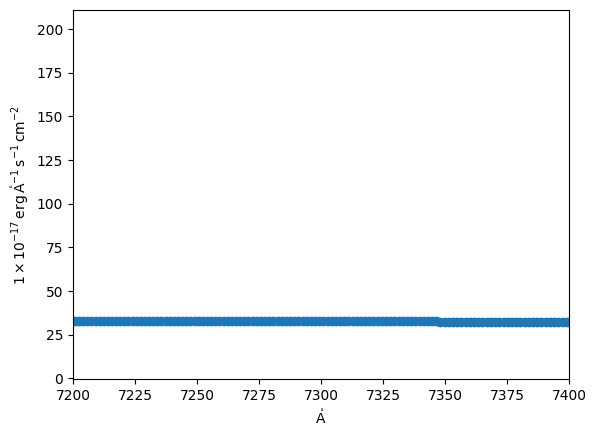

In [ ]:
f, ax = plt.subplots()
ax.step(spec.spectral_axis, spec.flux)

In [168]:
specdata['and_mask'],specdata['or_mask']

(array([0, 0, 0, ..., 4, 4, 4]), array([0, 0, 0, ..., 4, 4, 4]))

In [82]:
specdata['ivar'][specdata['and_mask'] > 0]

array([3.4580142 , 2.5414765 , 2.374527  , 2.5758245 , 2.7649248 ,
       2.799036  , 2.6404645 , 2.5127456 , 0.3638496 , 0.06007517,
       0.05734403, 0.17517461, 2.1381896 , 0.8415557 , 1.2936766 ,
       3.4857001 , 3.90504   , 3.297198  , 2.4392517 , 1.9201953 ,
       1.3707151 , 2.1319294 , 1.9005764 , 1.5922015 , 2.1510344 ,
       2.3058088 , 1.9449475 , 2.209488  , 1.8833116 , 3.2019947 ,
       1.7160054 , 0.70247   , 2.1988902 , 3.086742  , 4.496206  ,
       2.6556466 , 1.0062399 , 2.285133  , 0.85514015, 0.99399084,
       2.5854897 , 1.2047031 , 1.543589  , 3.4818943 , 2.126305  ,
       2.7081997 , 2.4131608 , 0.7784856 , 0.981876  , 2.8680077 ,
       3.2482853 , 1.0968103 , 1.9738233 , 1.4191352 , 0.7317395 ,
       2.403746  , 2.186115  , 2.2956812 , 1.4654006 , 1.7896054 ,
       2.7325544 , 1.3392752 , 1.2264507 , 2.9155576 , 1.7948729 ,
       0.46314645, 0.34276798, 1.4695137 , 1.5022327 , 2.3774433 ,
       0.6366753 , 0.29502663, 1.0873011 , 0.72516847, 0.41160

In [87]:
specdata['ivar'][np.where(specdata['and_mask'] > 0)[0]] = 0


Професійною практикою вважається встановлення ivar = 0 для всіх точок, де and_mask != 0, перед початком аналізу.

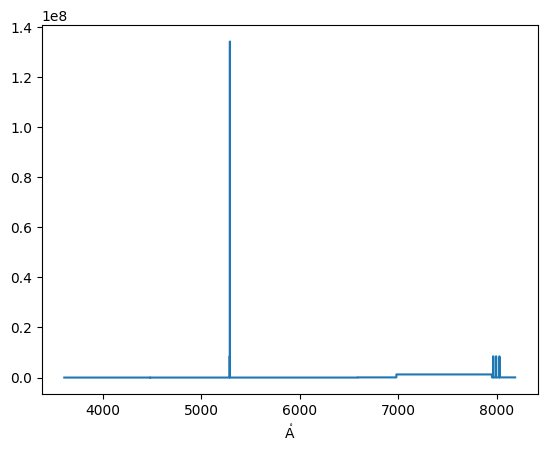

In [94]:
f, ax = plt.subplots()
ax.step(spec.spectral_axis, specdata['and_mask'])

In [121]:
import warnings

from specutils.fitting import fit_generic_continuum, fit_continuum

from specutils.analysis import snr
from specutils.analysis import line_flux
from specutils.analysis import centroid
from specutils.analysis import gaussian_sigma_width, gaussian_fwhm, fwhm, fwzi
from specutils.analysis import equivalent_width

def spec_line_info(spec, spec_region):
    
    with warnings.catch_warnings():  # Ignore warnings
        warnings.simplefilter('ignore')
        cont_norm_spec = spec / fit_generic_continuum(spec)(spec.spectral_axis)
        subtracted_spec = spec - fit_continuum(spec)(spec.wavelength)

    snr_ = snr(spec, region=spec_region)

    line_flux_ = line_flux(subtracted_spec, regions=spec_region)

    centroid_ = centroid(subtracted_spec, regions=spec_region)

    gaussian_sigma_width_ = gaussian_sigma_width(spec,regions=spec_region)
    gaussian_fwhm_ = gaussian_fwhm(spec,regions=spec_region)
    fwhm_ = fwhm(spec,regions=spec_region)
    try:
        fwzi_ = fwzi(subtracted_spec,regions=spec_region) #must be <subtracted_spec>
    except:
        fwzi_ = fwhm_.copy()
        for i, rg in enumerate(spec_region):
            try:
                fwzi_[i] = fwzi(subtracted_spec,regions=rg)
            except:
                fwzi_[i] = None

    equivalent_width_ = equivalent_width(cont_norm_spec, regions=spec_region)

    columns = ['snr', 'line_flux', 'centroid', 'gaussian_sigma_width',
            'gaussian_fwhm', 'fwhm', 'fwzi', 'equivalent_width']

#    return pd.DataFrame([[snr_.value, line_flux_.value, centroid_.value, gaussian_sigma_width_.value,
#                gaussian_fwhm_.value, fwhm_.value, fwzi_.value, equivalent_width_.value]],columns=columns)

    return pd.DataFrame(list(map(list, zip(*[snr_, line_flux_, centroid_, gaussian_sigma_width_,
                gaussian_fwhm_, fwhm_, fwzi_, equivalent_width_]))),columns=columns)

In [115]:
spec.wavelength[((O_II_1.upper > spec.wavelength) & (O_II_1.lower < spec.wavelength))]

<SpectralAxis [7311.045 , 7312.726 , 7314.4087, 7316.095 , 7317.7783, 7319.466 ,
   7321.15  , 7322.838 , 7324.523 , 7326.2075, 7327.897 , 7329.5825] Angstrom>

In [104]:
LINES_RANGE[0].lower < spec.wavelength

array([False, False, False, ...,  True,  True,  True])

In [58]:
lines_range[0].lower,lines_range[0].upper

(<Quantity 3717. Angstrom>, <Quantity 3737. Angstrom>)

In [112]:
temp = LINES_RANGE.copy()
for i, band in enumerate(LINES_RANGE):
    if not (spec.wavelength.min() < band.lower and band.upper < spec.wavelength.max()):
        temp[i] = None
        continue
    if not ((band.upper > spec.wavelength) & (band.lower < spec.wavelength)).any():
        temp[i] = None

temp

[Spectral Region, 1 sub-regions:
   (3717.0 Angstrom, 3737.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (4851.0 Angstrom, 4871.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (4353.0 Angstrom, 4373.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (4949.0 Angstrom, 4969.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (4997.0 Angstrom, 5017.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (6553.0 Angstrom, 6573.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (6538.0 Angstrom, 6558.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (6574.0 Angstrom, 6594.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (6707.0 Angstrom, 6727.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (6721.0 Angstrom, 6741.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (5866.0 Angstrom, 5886.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (3859.0 Angstrom, 3879.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (4092.0 Angstrom, 4112.0 Angstrom) ,
 Spectral Region, 1 sub-regions:
   (4330.0 Angstro

In [122]:
df = spec_line_info(spec,temp)
df.index = LINES_NAME

INFO: the associated NDData object was deleted and cannot be accessed anymore. You can prevent the NDData object from being deleted by assigning it to a variable. If this happened after unpickling make sure you pickle the parent not the uncertainty directly. [astropy.nddata.nduncertainty]


c:\Users\lrik\AppData\Local\Programs\Python\Python310\lib\site-packages\astropy\nddata\nduncertainty.py:1221: RuntimeWarning: divide by zero encountered in divide
  new_array = None if self.array is None else 1 / self.array


In [ ]:
df.ffill

In [74]:
df[df.duplicated(keep=False)] = None

In [75]:
df

,snr,line_flux,centroid,gaussian_sigma_width,gaussian_fwhm,fwhm,fwzi,equivalent_width
O_II,15.18579387664795,2.934248015006238 1e-17 erg / (s cm2),3702.182188727212 Angstrom,5.4754133224487305 Angstrom,12.89361304653178 Angstrom,15.213322905365658 Angstrom,13.560972174522005 Angstrom,-0.44319455203580516 Angstrom
H_B,25.715312957763672,2.8354355528461217 1e-17 erg / (s cm2),4857.677844155155 Angstrom,5.7069573402404785 Angstrom,13.43885754093479 Angstrom,19.02587890625 Angstrom,5.798368386107244 Angstrom,-0.4313861086285214 Angstrom
O_III_1,15.962966918945312,3.3665486831762346 1e-17 erg / (s cm2),4365.219813286634 Angstrom,5.768127918243408 Angstrom,13.58290324418222 Angstrom,19.0908203125 Angstrom,18.84976942724397 Angstrom,-0.5007198873932219 Angstrom
O_III_21,25.91988182067871,0.5993041571666332 1e-17 erg / (s cm2),4965.672663372746 Angstrom,5.861511707305908 Angstrom,13.802805262547535 Angstrom,19.41357421875 Angstrom,12.850525119981379 Angstrom,-0.14243359606724026 Angstrom
O_III_22,27.213953018188477,3.6335607766578395 1e-17 erg / (s cm2),5011.495560783214 Angstrom,5.517248630523682 Angstrom,12.99212766857672 Angstrom,18.44580078125 Angstrom,8.301631150001523 Angstrom,-0.5319941259176643 Angstrom
H_A,15.754613876342773,29.786452864291373 1e-17 erg / (s cm2),6565.180857347142 Angstrom,5.534960746765137 Angstrom,13.033836514942017 Angstrom,6.399216478564085 Angstrom,7.90407346478606 Angstrom,-5.361943659150666 Angstrom
N_II_1,15.720901489257812,7.327717817049594 1e-17 erg / (s cm2),6547.985135038082 Angstrom,5.939751148223877 Angstrom,13.987045066333183 Angstrom,19.5986328125 Angstrom,11.955820153502874 Angstrom,-1.2419200886831234 Angstrom
N_II_2,15.789398193359375,9.999356101274419 1e-17 erg / (s cm2),6585.606092599551 Angstrom,5.519802570343018 Angstrom,12.998141737257095 Angstrom,18.18994140625 Angstrom,9.526363448860517 Angstrom,-1.7480310513956177 Angstrom
S_II_1,12.664754867553711,9.334468778478238 1e-17 erg / (s cm2),6718.399981771698 Angstrom,5.64694881439209 Angstrom,13.297548261394248 Angstrom,18.5625 Angstrom,7.5358599386673095 Angstrom,-1.6605601168181403 Angstrom
S_II_2,7.533331871032715,-1.7938032592879072 1e-17 erg / (s cm2),6745.652815749936 Angstrom,5.725801944732666 Angstrom,13.483233193333675 Angstrom,4.135484343585631 Angstrom,4.722085690599219 Angstrom,0.44080012741559127 Angstrom


In [118]:
from specutils import Spectrum
from astropy.nddata import InverseVariance

def spec_estimate(j, data):
    name = file_name(j,data)
    spect = fits.open(file_path(j,data))
    specdata = spect[1].data

    #redshift
    wave = 10**specdata['loglam'] * u.AA / (1 + data.loc[j,'z'])
    flux = specdata['flux'] * u.Unit('1e-17 erg cm-2 s-1 AA-1')

    #
    specdata['ivar'][np.where(specdata['and_mask'] > 0)[0]] = 0
    uncertainty = InverseVariance(specdata['ivar'])

    spec = Spectrum(spectral_axis=wave, flux=flux, uncertainty=uncertainty)

    temp = LINES_RANGE.copy()
    for i, band in enumerate(LINES_RANGE):
        if not (spec.wavelength.min() < band.lower and band.upper < spec.wavelength.max()):
            temp[i] = None
            continue
        if not ((band.upper > spec.wavelength) & (band.lower < spec.wavelength)).any():
            temp[i] = None

    df = spec_line_info(spec,temp)
    df.index = LINES_NAME
    df[df.duplicated(keep=False)] = None

    df.to_csv(f'{sdss_general_path}/estimate/{name}.csv')

In [ ]:
for j in range(0,300,1):
    print(j)
    spec_estimate(j,data)

In [ ]:
df.to_csv(f'{sdss_general_path}/estimate/{file_name(j,data)}.csv')

In [254]:
spec_at_rest = spec

C:\Users\lrik\AppData\Local\Temp\ipykernel_19068\3235382492.py:7: RuntimeWarning: divide by zero encountered in power
  sigma = spec_at_rest.uncertainty.array**-0.5


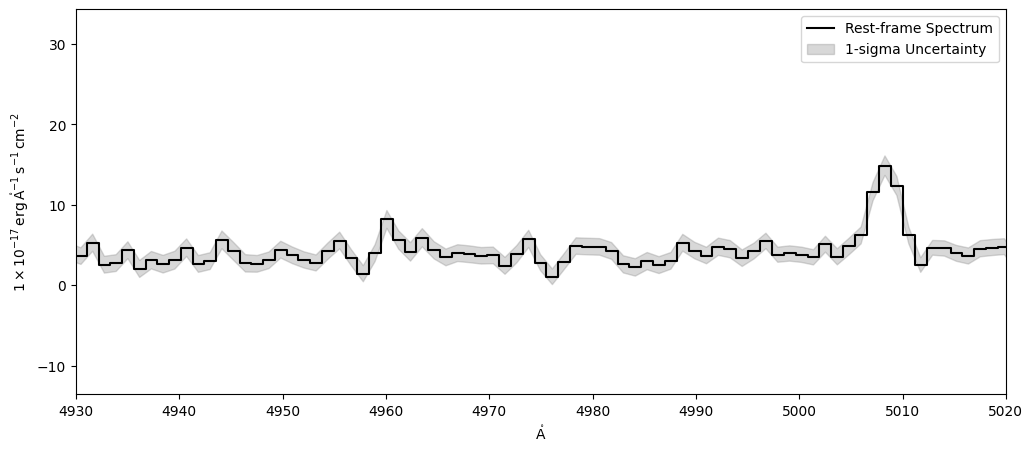

In [258]:
plt.figure(figsize=(12, 5))
# Малюємо основний спектр
plt.step(spec_at_rest.spectral_axis, spec_at_rest.flux, where='mid', color='black', label='Rest-frame Spectrum')

# Малюємо похибку (1-sigma) як напівпрозору область
# Пам'ятайте, що в SDSS ми витягли ivar, тому sigma = 1/sqrt(ivar)
sigma = spec_at_rest.uncertainty.array**-0.5
plt.fill_between(spec_at_rest.spectral_axis.value, 
                 spec_at_rest.flux.value - sigma, 
                 spec_at_rest.flux.value + sigma, 
                 color='gray', alpha=0.3, label='1-sigma Uncertainty')

plt.xlim(4930, 5020) # Фокусуємося на головних лініях Ca II та Mg b
plt.legend()
plt.show()

<h2> Dereddening </h2>

In [ ]:
from dust_extinction.parameter_averages import F99
ext = F99(Rv = 3.1)

In [ ]:
ra = data['RA']
dec = data['DEC']

from dustmaps.config import config
config['data_dir'] = ""
from astropy.coordinates import SkyCoord
from astropy import units as u
from dustmaps.sfd import SFDQuery
coords = SkyCoord(ra=ra, dec=dec, unit=(u.degree,u.degree))
del ra, dec
coords.galactic
sfd = SFDQuery()
ebv = sfd(coords)
del coords

In [ ]:
flux_ext = spec.flux * ext.extinguish(spec.spectral_axis, Ebv=ebv)
spec_ext = Spectrum(spectral_axis=wave, flux=flux_ext)

<h1> Normalization </h1>

Very complicated

In [172]:
fit_generic_continuum(spec,model=pol.Chebyshev1D(3, c0=0., c1=1., c2=1., c3=1.))(spec.spectral_axis)

<Quantity [3.78630551, 3.78641417, 3.78652292, ..., 1.89297552, 1.89153054,
           1.89008391] 1e-17 erg / (Angstrom s cm2)>

In [211]:
import warnings
from specutils.fitting import fit_generic_continuum
import astropy.modeling.polynomial as pol

with warnings.catch_warnings():  # Ignore warnings
    warnings.simplefilter('ignore')
    cont_norm_spec = spec / fit_generic_continuum(spec)(spec.spectral_axis)

INFO: the associated NDData object was deleted and cannot be accessed anymore. You can prevent the NDData object from being deleted by assigning it to a variable. If this happened after unpickling make sure you pickle the parent not the uncertainty directly. [astropy.nddata.nduncertainty]


In [210]:
from specutils.fitting.continuum import fit_continuum
fit_continuum(spec), fit_generic_continuum(spec)

INFO: the associated NDData object was deleted and cannot be accessed anymore. You can prevent the NDData object from being deleted by assigning it to a variable. If this happened after unpickling make sure you pickle the parent not the uncertainty directly. [astropy.nddata.nduncertainty]


(<QuantityModel Chebyshev1D(3, c0=1.64843643, c1=0.00108661, c2=-0.00000008, c3=0.), input_units=Angstrom, return_units=1e-17 erg / (Angstrom s cm2)>,
 <QuantityModel Chebyshev1D(3, c0=1.39062397, c1=0.00120677, c2=-0.00000009, c3=0.), input_units=Angstrom, return_units=1e-17 erg / (Angstrom s cm2)>)

INFO: the associated NDData object was deleted and cannot be accessed anymore. You can prevent the NDData object from being deleted by assigning it to a variable. If this happened after unpickling make sure you pickle the parent not the uncertainty directly. [astropy.nddata.nduncertainty]


(3.75, 3.8)

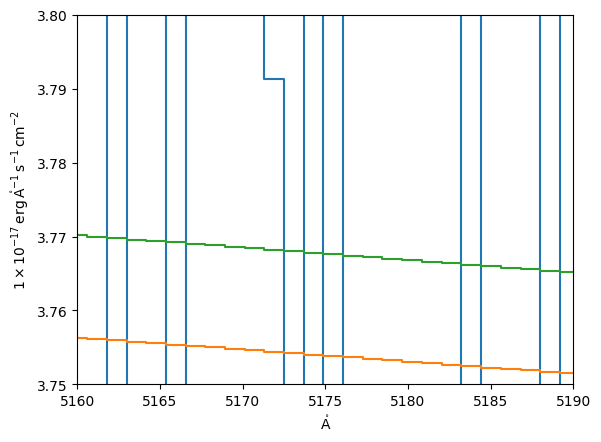

In [208]:
f, ax = plt.subplots()
ax.step(spec.wavelength, spec.flux)
ax.step(spec.wavelength, fit_generic_continuum(spec,model=pol.Chebyshev1D(3, c0=0., c1=1., c2=1., c3=1.))(spec.spectral_axis))
ax.step(spec.wavelength, fit_continuum(spec)(spec.wavelength))
#ax.step(spec.wavelength, fit_generic_continuum(spec,model=m)(spec.spectral_axis))
ax.set_xlim(516 * u.nm, 519 * u.nm)
ax.set_ylim(3.75,3.8)


Median

In [89]:
np.median(spec.flux)

<Quantity 3.2466118e-17 erg / (Angstrom s cm2)>

In [102]:
cont_norm_spec = spec / np.median(spec.flux)

<h2> the equivalent width of a spectral line </h2>

In [213]:
from specutils.analysis import equivalent_width
equivalent_width(cont_norm_spec, regions=SpectralRegion(5160 * u.AA, 5190 * u.AA))

<Quantity -13.02295559 Angstrom>

(5159.999999999999, 5189.999999999999)

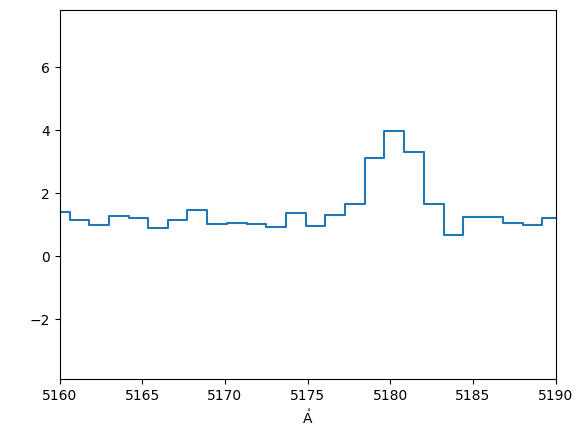

In [216]:
f, ax = plt.subplots()
ax.step(cont_norm_spec.wavelength, cont_norm_spec.flux)
#ax.step(spec.spectral_axis, spec.flux.value)
ax.set_xlim(516 * u.nm, 519 * u.nm)